 DE_IP_2024 — домашнее задание №1 и №2

Задание 1 Найти наиболее протяжённый участок изображения и выделить его одной красной линией при помощи преобразования Хафа.

Задание 2 Исследовать алгоритмы бинаризации и выделить участок дорожной полосы.

Размер изображения: 225 x 225


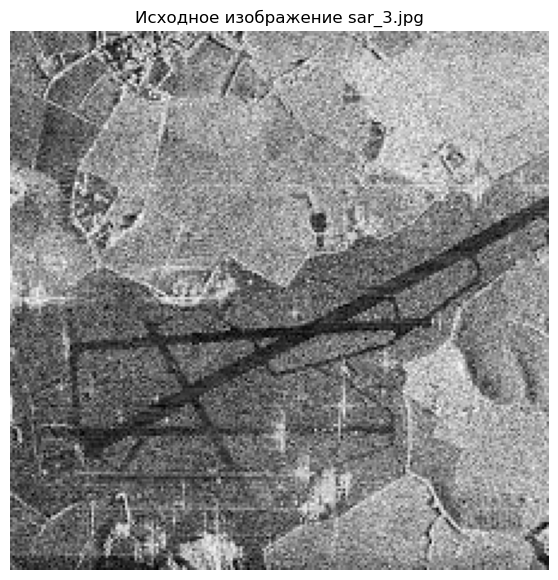

In [1]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['image.cmap'] = 'gray'

IMAGE_PATH = Path('sar_3.jpg')
IMAGE_URL = (
    'https://sc04.alicdn.com/kf/'
    'A14d41aa409274c35bf2c43d2d9222ac9T.jpg'
)

if not IMAGE_PATH.exists():
    print('Файл sar_3.jpg не найден. Загружаю приложенное изображение...')
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise FileNotFoundError(f'Не удалось прочитать изображение: {IMAGE_PATH.resolve()}')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
height, width = image_gray.shape

print(f'Размер изображения: {width} x {height}')
plt.figure(figsize=(7, 7))
plt.imshow(image_rgb)
plt.title('Исходное изображение sar_3.jpg')
plt.axis('off');

 Задание 1. Поиск наиболее протяжённого участка методом Хафа

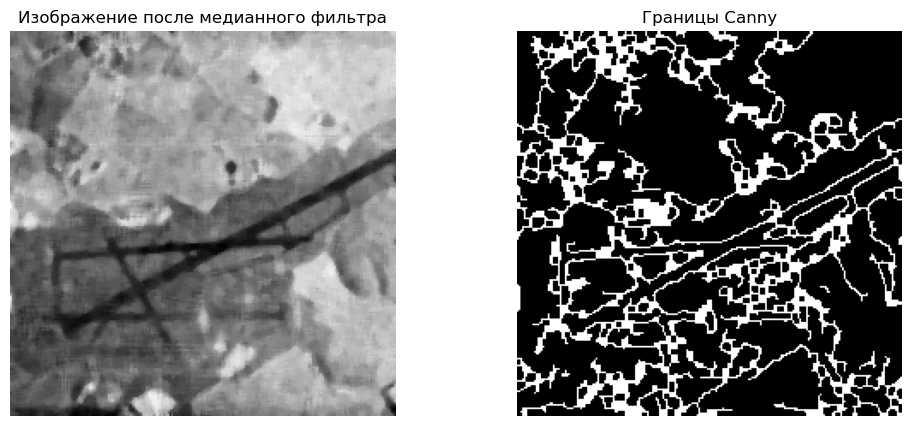

In [2]:
gray_for_edges = cv2.medianBlur(image_gray, 5)
edges = cv2.Canny(gray_for_edges, threshold1=50, threshold2=150, apertureSize=3)

morph_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, morph_kernel, iterations=1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_for_edges)
plt.title('Изображение после медианного фильтра')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(edges_closed)
plt.title('Границы Canny')
plt.axis('off');

Всего найдено отрезков: 175
Наиболее протяжённый участок: длина = 262.7 пикс., угол = 35.1°, координаты = (9, 54) -> (224, 205)


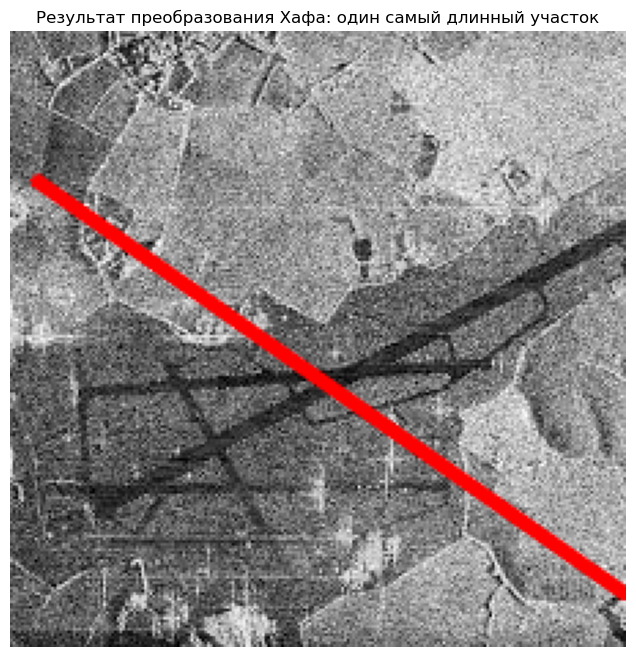

In [3]:
min_line_length = max(30, int(0.20 * min(height, width)))
max_line_gap = max(10, int(0.08 * min(height, width)))

lines_p = cv2.HoughLinesP(
    edges_closed,
    rho=1,
    theta=np.pi / 180,
    threshold=30,
    minLineLength=min_line_length,
    maxLineGap=max_line_gap
)

if lines_p is None:
    raise RuntimeError('Преобразование Хафа не обнаружило отрезков.')

segments = []
for line in lines_p[:, 0, :]:
    x1, y1, x2, y2 = map(int, line)
    length = float(np.hypot(x2 - x1, y2 - y1))
    angle = float(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
    segments.append((length, angle, x1, y1, x2, y2))

segments.sort(key=lambda item: item[0], reverse=True)
longest = segments[0]
length, angle, x1, y1, x2, y2 = longest

print(f'Всего найдено отрезков: {len(segments)}')
print(
    'Наиболее протяжённый участок: '
    f'длина = {length:.1f} пикс., угол = {angle:.1f}°, '
    f'координаты = ({x1}, {y1}) -> ({x2}, {y2})'
)

hough_result = image_rgb.copy()
cv2.line(hough_result, (x1, y1), (x2, y2), (255, 0, 0), 3, cv2.LINE_AA)

plt.figure(figsize=(8, 8))
plt.imshow(hough_result)
plt.title('Результат преобразования Хафа: один самый длинный участок')
plt.axis('off');

 Задание 2. Исследование бинаризации и выделение дорожной полосы

Порог Отсу: 129.0


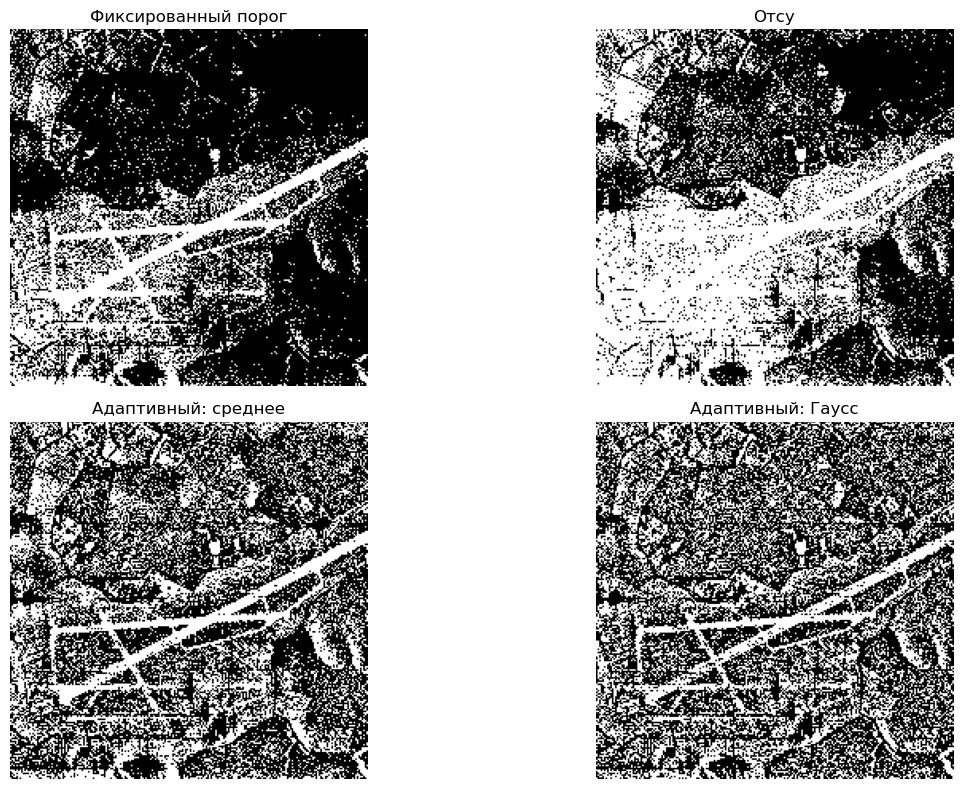

In [4]:
fixed_threshold = 100
_, binary_fixed = cv2.threshold(
    image_gray, fixed_threshold, 255, cv2.THRESH_BINARY_INV
)

otsu_threshold, binary_otsu = cv2.threshold(
    image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

adaptive_mean = cv2.adaptiveThreshold(
    image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV, 31, 7
)
adaptive_gaussian = cv2.adaptiveThreshold(
    image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 31, 7
)

print(f'Порог Отсу: {otsu_threshold:.1f}')

binary_images = [
    ('Фиксированный порог', binary_fixed),
    ('Отсу', binary_otsu),
    ('Адаптивный: среднее', adaptive_mean),
    ('Адаптивный: Гаусс', adaptive_gaussian),
]

plt.figure(figsize=(14, 8))
for index, (title, binary) in enumerate(binary_images, start=1):
    plt.subplot(2, 2, index)
    plt.imshow(binary)
    plt.title(title)
    plt.axis('off')
plt.tight_layout();

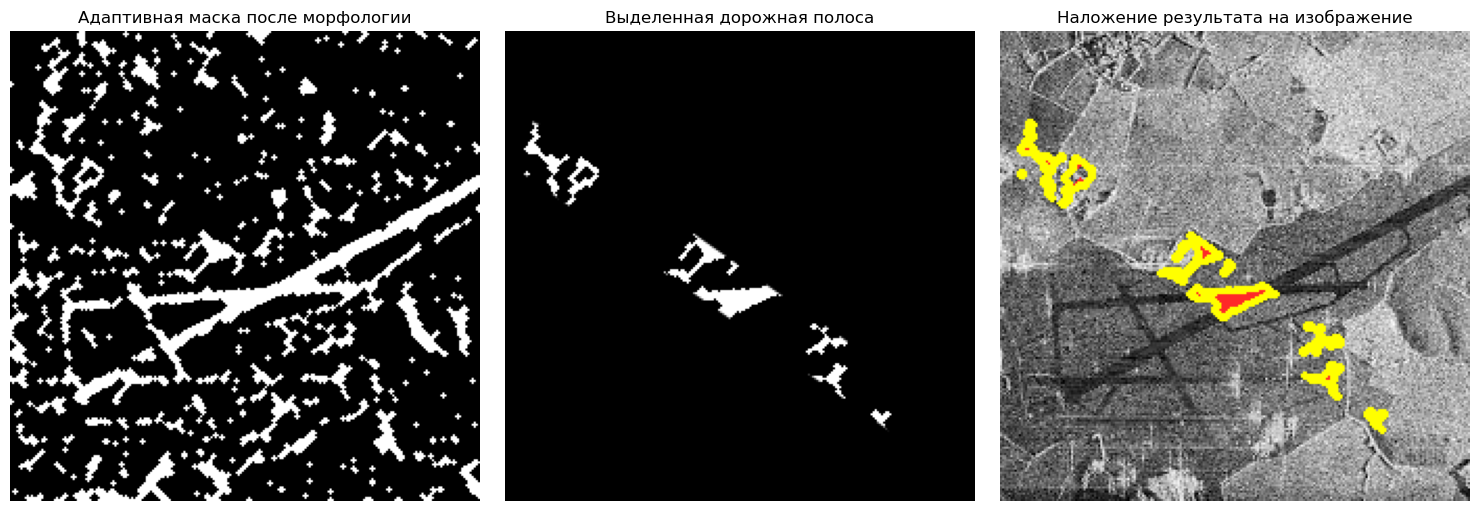

In [5]:
road_binary = adaptive_gaussian.copy()
noise_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
road_binary = cv2.morphologyEx(road_binary, cv2.MORPH_OPEN, noise_kernel, iterations=1)
road_binary = cv2.morphologyEx(road_binary, cv2.MORPH_CLOSE, noise_kernel, iterations=2)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    road_binary, connectivity=8
)
component_mask = np.zeros_like(road_binary)
min_component_area = max(20, int(0.002 * height * width))
for label in range(1, num_labels):
    area = stats[label, cv2.CC_STAT_AREA]
    if area >= min_component_area:
        component_mask[labels == label] = 255

line_band = np.zeros_like(road_binary)
band_width = max(10, int(0.10 * min(height, width)))
cv2.line(line_band, (x1, y1), (x2, y2), 255, band_width, cv2.LINE_AA)
road_mask = cv2.bitwise_and(component_mask, line_band)

if cv2.countNonZero(road_mask) < 0.002 * height * width:
    road_mask = component_mask

road_overlay = image_rgb.copy()
road_overlay[road_mask > 0] = (255, 40, 40)
road_contours, _ = cv2.findContours(
    road_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
cv2.drawContours(road_overlay, road_contours, -1, (255, 255, 0), 2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(road_binary)
plt.title('Адаптивная маска после морфологии')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(road_mask)
plt.title('Выделенная дорожная полоса')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(road_overlay)
plt.title('Наложение результата на изображение')
plt.axis('off')
plt.tight_layout();